In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
path = '/content/sample_data/all-data.csv'
df = pd.read_csv(path, encoding='latin1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
df.head()

,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing ."
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [28]:
df.isnull().sum()

,0
neutral,0
"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",0


In [29]:
from sklearn.preprocessing import LabelEncoder

# Rename the first column to 'sentiment' for clarity
df = df.rename(columns={df.columns[0]: 'sentiment'})

le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

In [30]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()


In [31]:
x=df.iloc[ : ,3:].values
x

array([], shape=(4845, 0), dtype=float64)

In [32]:
import scipy.cluster.hierarchy as sch
dendrogram=sch.dendrogram(sch.linkage(x,method='ward'))
plt.title('Dendogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

RecursionError: maximum recursion depth exceeded

In [ ]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
y_hc=hc.fit_predict(x)
y_hc

In [ ]:
plt.scatter(x[y_hc==0,0],x[y_hc==0,1],s=100,c='red',label='Cluster 1')
plt.scatter(x[y_hc==1 ,0],x[y_hc==1,1],s=100,c='blue',label='Cluster 2')
plt.scatter(x[y_hc==2 ,0],x[y_hc==2,1],s=100,c='green',label='Cluster 3')
plt.scatter(x[y_hc==3 ,0],x[y_hc==3,1],s=100,c='cyan',label='Cluster 4')
plt.scatter(x[y_hc==4,0],x[y_hc==4 ,1],s=100,c="pink",label='Cluster 5')
plt.xlabel("salary")
plt.ylabel("aount spend")
plt.title("title")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(x,y_hc)
score

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path = '/content/sample_data/all-data.csv'
df = pd.read_csv(path, encoding='latin1')

In [ ]:
df.head()

In [ ]:
df.isnull().sum()

In [ ]:
x=df.iloc[: ,0 :]
x

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch


from sklearn.metrics import silhouette_score


path = '/content/sample_data/all-data.csv'

# Dataset has no header
df = pd.read_csv(path, encoding='latin1', header=None)

# Give column names
df.columns = ['sentiment', 'text']

print("Dataset Preview")
print(df.head())


tfidf = TfidfVectorizer(
    stop_words='english',   # remove common words
    max_features=2000       # top important words
)

# Transform text to numeric matrix
X = tfidf.fit_transform(df['text']).toarray()

print("TFIDF Shape:", X.shape)


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



plt.figure(figsize=(12,6))

dendrogram = sch.dendrogram(
    sch.linkage(X_scaled, method='ward')
)

plt.title("Dendrogram")
plt.xlabel("Documents")
plt.ylabel("Euclidean Distance")
plt.show()

k = 2
1hc = AgglomerativeClustering(
    n_clusters=k,
    metric='euclidean',
    linkage='ward'
)

labels = hc.fit_predict(X_scaled)

df['cluster'] = labels


score = silhouette_score(X_scaled, labels)

print("\n============================")
print("Silhouette Score:", score)
print("============================\n")



for i in range(k):
    print(f"\n---- Cluster {i} ----")
    print(df[df['cluster']==i]['text'].head(3))

print("\nSentiment vs Cluster Table\n")
print(pd.crosstab(df['sentiment'], df['cluster']))


df.to_csv("hierarchical_result.csv", index=False)

print("\nSaved output to hierarchical_result.csv")


In [ ]:
feature_names = tfidf.get_feature_names_out()
for cluster in range(k):
    print(f"\nCluster {cluster}")

    cluster_indices = np.where(labels == cluster)
    cluster_tfidf = X_scaled[cluster_indices]

    mean_tfidf = np.mean(cluster_tfidf, axis=0)
    top_indices = mean_tfidf.argsort()[-10:][::-1]

    top_words = [feature_names[i] for i in top_indices]
    print("Top Words:", top_words)

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
path = '/content/sample_data/Mall_Customers.csv'
df = pd.read_csv(path, encoding='latin1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [36]:
x=df[['Annual Income (k$)','Spending Score (1-100)']]

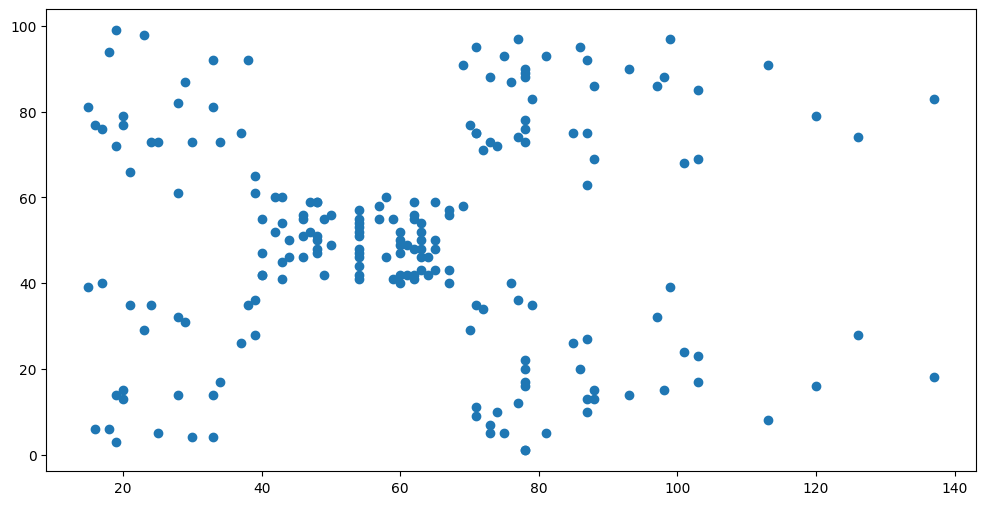

In [37]:
plt.figure(figsize=(12,6))
plt.scatter(x['Annual Income (k$)'],x['Spending Score (1-100)'])
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x=sc.fit_transform(x)

In [100]:
;

''

In [64]:
from sklearn.metrics import silhouette_score
score = silhouette_score(x,clusters)
score

np.float64(0.41325830390002166)

In [65]:
eps_values=[0.2,0.3,0.4,0.5]
for eps in eps_values:
  print("evaluating dbscan using eps",eps)
  dbscan = DBSCAN(eps=eps,min_samples=5)
  clusters = dbscan.fit_predict(x)
  print("noise")
  unique_labels=set(clusters)
  n_clusters=len(unique_labels)-(1 if -1 in unique_labels else 0)
  print("number of clusters",n_clusters)
  n_noise=list(clusters)
  noise_ratio=n_noise.count(-1)/len(clusters)
  print("noise ratio",noise_ratio)
  print("number of noise points",round(noise_ratio,2))
  #shihoutte score:
  score = silhouette_score(x,clusters)
  print("silhouette score",score)

evaluating dbscan using eps 0.2
noise
number of clusters 7
noise ratio 0.385
number of noise points 0.39
silhouette score 0.14057942679617558
evaluating dbscan using eps 0.3
noise
number of clusters 7
noise ratio 0.175
number of noise points 0.17
silhouette score 0.31614121976731185
evaluating dbscan using eps 0.4
noise
number of clusters 4
noise ratio 0.075
number of noise points 0.07
silhouette score 0.41325830390002166
evaluating dbscan using eps 0.5
noise
number of clusters 2
noise ratio 0.04
number of noise points 0.04
silhouette score 0.35044619989666004


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
path = '/content/train.csv'
df = pd.read_csv(path, encoding='latin1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [4]:
df=df.drop(columns=['id','pickup_datetime','dropoff_datetime'])

In [5]:
df.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


In [6]:
df.dropna(subset=['dropoff_latitude','store_and_fwd_flag','trip_duration'],inplace=True)

In [7]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [8]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
le=LabelEncoder()
df['store_and_fwd_flag']=le.fit_transform(df['store_and_fwd_flag'])
x=df.iloc[1 :290 ,0 :].values
x

array([['id2377394', 1, '2016-06-12 00:43:35', ..., 40.731151580810554,
        0, 663],
       ['id3858529', 2, '2016-01-19 11:35:24', ..., 40.710086822509766,
        0, 2124],
       ['id3504673', 2, '2016-04-06 19:32:31', ..., 40.70671844482422, 0,
        429],
       ...,
       ['id2808378', 1, '2016-03-09 17:11:16', ..., 40.70158767700195, 0,
        1047],
       ['id2015130', 2, '2016-05-21 03:13:55', ..., 40.74769973754882, 0,
        404],
       ['id1062725', 1, '2016-06-08 05:51:58', ..., 40.75728988647461, 0,
        356]], dtype=object)

In [1]:
import pandas as pd
from google.colab import drive
from sklearn.preprocessing import LabelEncoder

drive.mount('/content/drive')
path = '/content/train.csv'
df = pd.read_csv(path, encoding='latin1')

df = df.drop(columns=['id', 'pickup_datetime', 'dropoff_datetime'])
df.dropna(subset=['dropoff_latitude', 'store_and_fwd_flag', 'trip_duration'], inplace=True)

le = LabelEncoder()
df['store_and_fwd_flag'] = le.fit_transform(df['store_and_fwd_flag'])

x = df[['pickup_longitude', 'pickup_latitude']]
x = x[
    (x['pickup_latitude'].between(-90, 90)) &
    (x['pickup_longitude'].between(-180, 180))
]
x = x[
    (x['pickup_latitude'].between(40, 41)) &
    (x['pickup_longitude'].between(-75, -72))
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


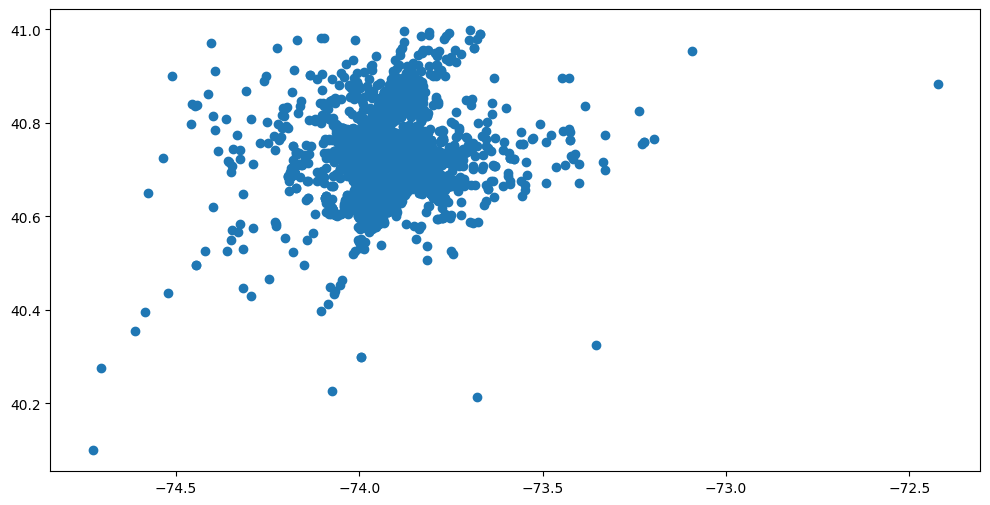

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.scatter(x['pickup_longitude'], x['pickup_latitude'])
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
eps_values=[0.2]
for eps in eps_values:
  print("evaluating dbscan using eps",eps)
  dbscan = DBSCAN(eps=eps,min_samples=5)
  clusters = dbscan.fit_predict(x)
  print("noise")
  unique_labels=set(clusters)
  n_clusters=len(unique_labels)-(1 if -1 in unique_labels else 0)
  print("number of clusters",n_clusters)
  n_noise=list(clusters)
  noise_ratio=n_noise.count(-1)/len(clusters)
  print("noise ratio",noise_ratio)
  print("number of noise points",round(noise_ratio,2))
  #shihoutte score:
  score = silhouette_score(x,clusters)
  print("silhouette score",score)

evaluating dbscan using eps 0.2
